In [13]:
import netCDF4 as nc
import os

# 文件路径
ini_path = "/sugon7/zsm/croco_tools_xmd1204/CROCO_FILES/TWS2/bio2_TWS_L1_ini.nc"

# 1. 以追加模式打开文件（'a'）
# 注意：不要使用 'r+' 或 'w'，'a' 是最安全的修改模式
ds = nc.Dataset(ini_path, 'a')

print("文件打开成功！")
# print("原始 hc 值:", ds.hc)

# 2. 修改 hc 属性
# 注意：hc 在 NetCDF 中通常是 float 或 double
# ds.hc = 10  # 设置为 2.0
ds.Tcline=10
HC=ds.variables['hc']
HC[:]=10
Tcline=ds.variables['Tcline']
Tcline[:]=10
TALK=ds.variables['Talk']
TALK[:]=2300
# Tcline=ds.variables['Tcline']

OT=ds.variables['ocean_time']
OT[:]=604972800

# print("修改后 hc 值:", ds.hc)

# 3. 同步并关闭文件
ds.sync()  # 确保写入磁盘
ds.close()

print("✅ 属性 hc 已成功修改为 10")

文件打开成功！
✅ 属性 hc 已成功修改为 10


In [6]:
import xarray as xr
fname='/leader/user/zsm/TWS2_L1_ucla_new/sample_files/s2sflux_spec_twstide.0002.nc'
ds=xr.open_dataset(fname)
ds

<xarray.Dataset> Size: 384B
Dimensions:    (filtscale: 32)
Coordinates:
  * filtscale  (filtscale) float32 128B 500.0 1e+03 1.5e+03 ... 3.3e+04 3.6e+04
Data variables:
    Thm        (filtscale) float32 128B ...
    Ekm        (filtscale) float32 128B ...

In [7]:
Thm=ds['Thm'].values
xscale=ds['filtscale'].values

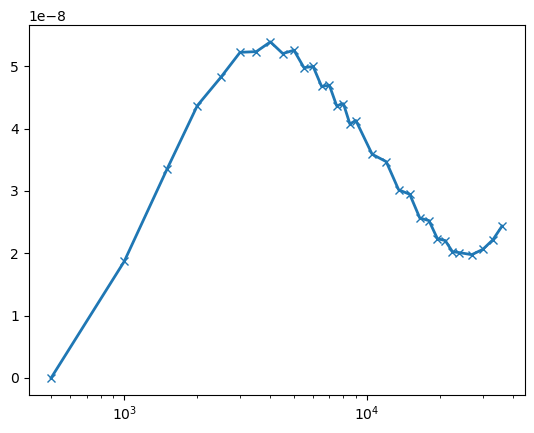

In [8]:
from matplotlib import pyplot as plt

plt.semilogx(xscale,Thm,marker='x',linewidth=2,linestyle='-')